# Tesla Sales and Price ML Pipeline

End-to-end machine learning workflow covering preprocessing, EDA, feature engineering, regression modeling, hyperparameter tuning, and time series forecasting on Tesla delivery and price data.

In [10]:
from __future__ import annotations

import json
import os
import warnings
from pathlib import Path

os.environ['LOKY_MAX_CPU_COUNT'] = '1'
warnings.filterwarnings('ignore', category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
ROOT = Path.cwd()
DATA_PATH = ROOT.parent / 'tesla_deliveries_dataset_2015_2025.csv'
OUTPUT_DIR = ROOT / 'ml_pipeline_outputs'
TARGET = 'Estimated_Deliveries'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_PATH

WindowsPath('c:/Users/khush/OneDrive/Desktop/tesla_deliveries_dataset_2015_2025.csv')

## 1. Load and Preprocess Data

In [11]:
def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)


def load_data(path: Path = DATA_PATH) -> pd.DataFrame:
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(
        df['Year'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2) + '-01'
    )
    return df.sort_values('date').reset_index(drop=True)


df = load_data()
print(df.shape)
display(df.head())
display(df.info())

(2640, 13)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,date
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Year                  2640 non-null   int64         
 1   Month                 2640 non-null   int64         
 2   Region                2640 non-null   object        
 3   Model                 2640 non-null   object        
 4   Estimated_Deliveries  2640 non-null   int64         
 5   Production_Units      2640 non-null   int64         
 6   Avg_Price_USD         2640 non-null   float64       
 7   Battery_Capacity_kWh  2640 non-null   int64         
 8   Range_km              2640 non-null   int64         
 9   CO2_Saved_tons        2640 non-null   float64       
 10  Source_Type           2640 non-null   object        
 11  Charging_Stations     2640 non-null   int64         
 12  date                  2640 non-null   datetime64[ns]
dtypes: datetime64[ns](

None

## 2. Exploratory Data Analysis

In [12]:
eda_dir = OUTPUT_DIR / 'eda'
eda_dir.mkdir(parents=True, exist_ok=True)

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
summary = {
    'shape': list(df.shape),
    'date_min': str(df['date'].min().date()),
    'date_max': str(df['date'].max().date()),
    'missing_values': df.isna().sum().to_dict(),
    'numeric_summary': df[numeric_cols].describe().round(3).to_dict(),
    'region_counts': df['Region'].value_counts().to_dict(),
    'model_counts': df['Model'].value_counts().to_dict(),
}
(eda_dir / 'eda_summary.json').write_text(json.dumps(summary, indent=2))

monthly = df.groupby('date', as_index=False).agg(
    deliveries=(TARGET, 'sum'),
    avg_price=('Avg_Price_USD', 'mean'),
    production=('Production_Units', 'sum'),
)
monthly.to_csv(eda_dir / 'monthly_sales_price_summary.csv', index=False)

display(df.describe(include='all'))
display(monthly.head())

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,date
count,2640.000000,2640.000000,2640,2640,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640,2640.000000,2640
unique,NaN,NaN,4,5,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN
top,NaN,NaN,Asia,Model Y,NaN,NaN,NaN,NaN,NaN,NaN,Official (Quarter),NaN,NaN
freq,NaN,NaN,660,528,NaN,NaN,NaN,NaN,NaN,NaN,884,NaN,NaN
mean,2020.000000,6.500000,NaN,NaN,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,NaN,8932.133712,2020-06-16 02:10:54.545454592
min,2015.000000,1.000000,NaN,NaN,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,NaN,3002.000000,2015-01-01 00:00:00
25%,2017.000000,3.750000,NaN,NaN,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,NaN,5897.750000,2017-09-23 12:00:00
50%,2020.000000,6.500000,NaN,NaN,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,NaN,8901.500000,2020-06-16 00:00:00
75%,2023.000000,9.250000,NaN,NaN,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,NaN,11938.000000,2023-03-08 18:00:00
max,2025.000000,12.000000,NaN,NaN,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,NaN,14996.000000,2025-12-01 00:00:00


,date,deliveries,avg_price,production
0,2015-01-01,183180,84502.4970,195793
1,2015-02-01,165053,81745.5695,176119
2,2015-03-01,184567,86221.2895,200151
3,2015-04-01,225623,83446.1640,241706
4,2015-05-01,184264,85632.1110,198205


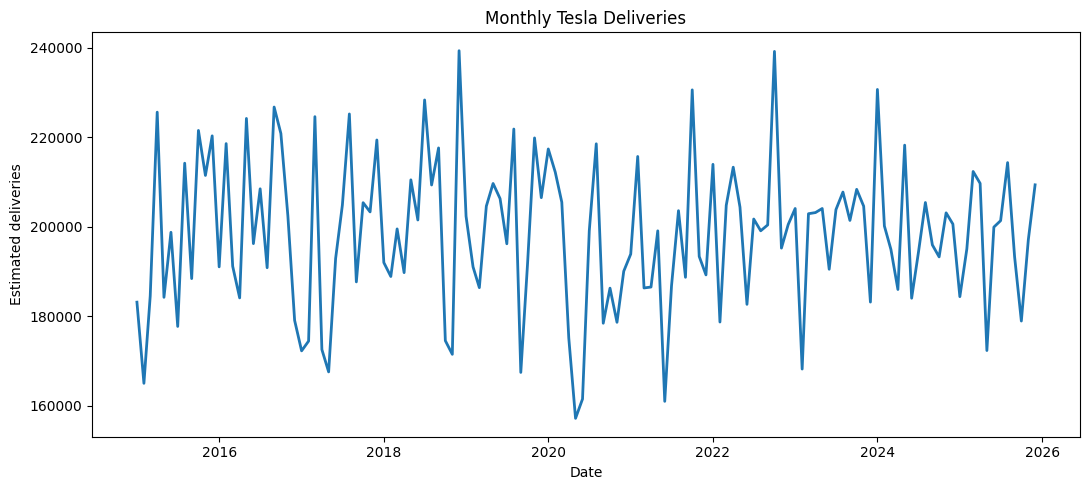

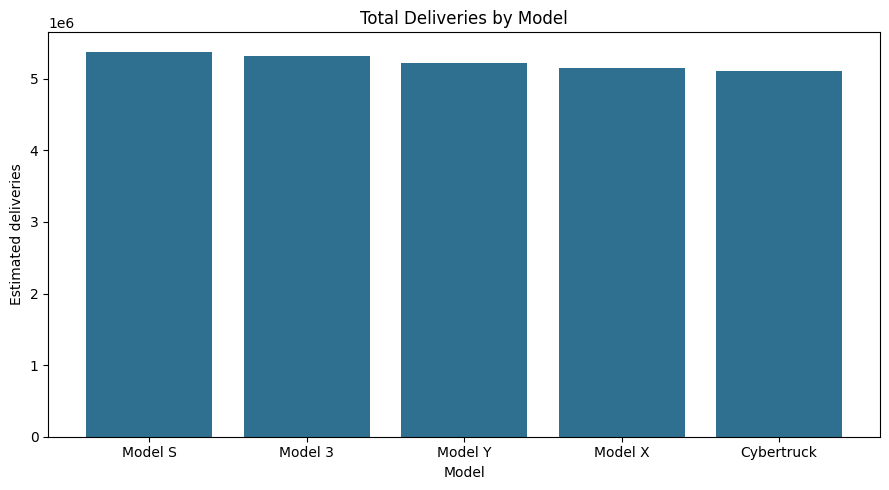

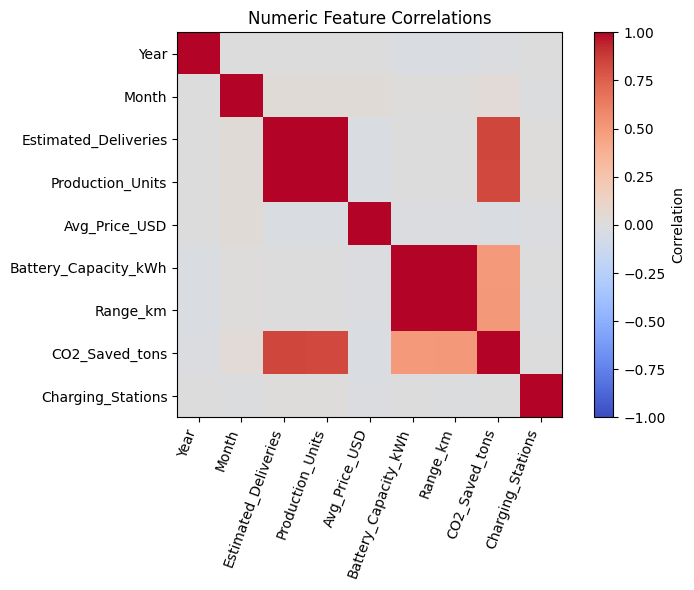

In [13]:
plt.figure(figsize=(11, 5))
plt.plot(monthly['date'], monthly['deliveries'], label='Deliveries', linewidth=2)
plt.title('Monthly Tesla Deliveries')
plt.xlabel('Date')
plt.ylabel('Estimated deliveries')
plt.tight_layout()
plt.savefig(eda_dir / 'monthly_deliveries.png', dpi=140)
plt.show()

by_model = df.groupby('Model')[TARGET].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(9, 5))
plt.bar(by_model['Model'], by_model[TARGET], color='#2f6f8f')
plt.title('Total Deliveries by Model')
plt.xlabel('Model')
plt.ylabel('Estimated deliveries')
plt.tight_layout()
plt.savefig(eda_dir / 'deliveries_by_model.png', dpi=140)
plt.show()

corr = df[numeric_cols].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=70, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Numeric Feature Correlations')
plt.tight_layout()
plt.savefig(eda_dir / 'correlation_heatmap.png', dpi=140)
plt.show()

## 3. Feature Engineering

In [14]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['quarter'] = out['date'].dt.quarter
    out['month_sin'] = np.sin(2 * np.pi * out['Month'] / 12)
    out['month_cos'] = np.cos(2 * np.pi * out['Month'] / 12)
    out['price_per_kwh'] = out['Avg_Price_USD'] / out['Battery_Capacity_kWh'].replace(0, np.nan)
    out['range_per_kwh'] = out['Range_km'] / out['Battery_Capacity_kWh'].replace(0, np.nan)

    group_cols = ['Region', 'Model']
    out = out.sort_values(group_cols + ['date']).reset_index(drop=True)
    grouped = out.groupby(group_cols, sort=False)
    out['deliveries_lag_1'] = grouped[TARGET].shift(1)
    out['deliveries_lag_3'] = grouped[TARGET].shift(3)
    out['price_lag_1'] = grouped['Avg_Price_USD'].shift(1)
    out['deliveries_roll_3'] = grouped[TARGET].transform(
        lambda series: series.shift(1).rolling(3, min_periods=1).mean()
    )
    out['price_roll_3'] = grouped['Avg_Price_USD'].transform(
        lambda series: series.shift(1).rolling(3, min_periods=1).mean()
    )
    return out.sort_values('date').reset_index(drop=True)


featured = add_features(df)
featured.to_csv(OUTPUT_DIR / 'engineered_tesla_deliveries.csv', index=False)
display(featured.head())

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,...,quarter,month_sin,month_cos,price_per_kwh,range_per_kwh,deliveries_lag_1,deliveries_lag_3,price_lag_1,deliveries_roll_3,price_roll_3
0,2015,1,Asia,Cybertruck,11325,11887,54449.08,60,339,575.88,...,1,0.5,0.866025,907.484667,5.650000,NaN,NaN,NaN,NaN,NaN
1,2015,1,North America,Model 3,9446,9528,110632.33,75,435,616.35,...,1,0.5,0.866025,1475.097733,5.800000,NaN,NaN,NaN,NaN,NaN
2,2015,1,North America,Model S,11986,13302,91906.09,82,457,821.64,...,1,0.5,0.866025,1120.805976,5.573171,NaN,NaN,NaN,NaN,NaN
3,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,...,1,0.5,0.866025,1073.033293,5.560976,NaN,NaN,NaN,NaN,NaN
4,2015,1,Europe,Model S,4350,4736,53251.53,82,475,309.94,...,1,0.5,0.866025,649.408902,5.792683,NaN,NaN,NaN,NaN,NaN


## 4. Regression Modeling and Hyperparameter Tuning

In [15]:
feature_cols = [
    'Year', 'Month', 'quarter', 'month_sin', 'month_cos', 'Region', 'Model',
    'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
    'CO2_Saved_tons', 'Source_Type', 'Charging_Stations', 'price_per_kwh',
    'range_per_kwh', 'deliveries_lag_1', 'deliveries_lag_3', 'price_lag_1',
    'deliveries_roll_3', 'price_roll_3'
]

train_mask = featured['date'] < pd.Timestamp('2024-01-01')
train_df = featured.loc[train_mask].copy()
test_df = featured.loc[~train_mask].copy()
x_train, y_train = train_df[feature_cols], train_df[TARGET]
x_test, y_test = test_df[feature_cols], test_df[TARGET]

categorical_cols = featured[feature_cols].select_dtypes(include=['object', 'category']).columns.tolist()
numeric_feature_cols = [col for col in feature_cols if col not in categorical_cols]

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', make_one_hot_encoder()),
])
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_feature_cols),
    ('cat', categorical_pipeline, categorical_cols),
])

def evaluate_model(name: str, model: Pipeline) -> dict[str, float | str]:
    preds = model.predict(x_test)
    return {
        'model': name,
        'MAE': round(mean_absolute_error(y_test, preds), 3),
        'RMSE': round(float(np.sqrt(mean_squared_error(y_test, preds))), 3),
        'R2': round(r2_score(y_test, preds), 4),
    }

candidates = {
    'Ridge': Ridge(random_state=RANDOM_STATE),
    'RandomForest': RandomForestRegressor(n_estimators=250, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1),
    'HistGradientBoosting': HistGradientBoostingRegressor(random_state=RANDOM_STATE),
}

results = []
for name, regressor in candidates.items():
    pipe = Pipeline([('preprocess', preprocessor), ('model', regressor)])
    pipe.fit(x_train, y_train)
    results.append(evaluate_model(name, pipe))

model_dir = OUTPUT_DIR / 'modeling'
model_dir.mkdir(parents=True, exist_ok=True)
baseline_metrics = pd.DataFrame(results).sort_values('RMSE')
baseline_metrics.to_csv(model_dir / 'baseline_model_metrics.csv', index=False)
display(baseline_metrics)

,model,MAE,RMSE,R2
2,HistGradientBoosting,280.958,350.734,0.9911
0,Ridge,321.163,390.722,0.9890
1,RandomForest,339.649,419.990,0.9873


In [16]:
tuning_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', HistGradientBoostingRegressor(random_state=RANDOM_STATE)),
])
param_grid = {
    'model__learning_rate': [0.03, 0.06, 0.1],
    'model__max_iter': [150, 250],
    'model__max_leaf_nodes': [15, 31, 63],
    'model__l2_regularization': [0.0, 0.05, 0.1],
}
search = GridSearchCV(
    tuning_pipe,
    param_grid=param_grid,
    cv=TimeSeriesSplit(n_splits=4),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)
search.fit(x_train, y_train)

tuned_metrics = evaluate_model('TunedHistGradientBoosting', search.best_estimator_)
tuned_metrics['best_params'] = json.dumps(search.best_params_)
tuned_metrics_df = pd.DataFrame([tuned_metrics])
tuned_metrics_df.to_csv(model_dir / 'tuned_model_metrics.csv', index=False)

holdout_predictions = test_df[['date', 'Region', 'Model', TARGET]].copy()
holdout_predictions['predicted_deliveries'] = search.best_estimator_.predict(x_test).round(0)
holdout_predictions.to_csv(model_dir / 'holdout_predictions_2024_2025.csv', index=False)

display(tuned_metrics_df)
display(holdout_predictions.head())

,model,MAE,RMSE,R2,best_params
0,TunedHistGradientBoosting,303.026,373.423,0.99,"{""model__l2_regularization"": 0.1, ""model__lear..."


,date,Region,Model,Estimated_Deliveries,predicted_deliveries
2160,2024-01-01,Middle East,Cybertruck,9756,9481.0
2161,2024-01-01,North America,Model S,12668,13124.0
2162,2024-01-01,North America,Model Y,15314,15115.0
2163,2024-01-01,North America,Model X,7363,7197.0
2164,2024-01-01,North America,Cybertruck,8771,9185.0


## 5. Time Series Forecasting

In [17]:
forecast_dir = OUTPUT_DIR / 'forecasting'
forecast_dir.mkdir(parents=True, exist_ok=True)

monthly_ts = featured.groupby('date', as_index=False).agg(
    deliveries=(TARGET, 'sum'),
    avg_price=('Avg_Price_USD', 'mean'),
    production=('Production_Units', 'sum'),
    charging_stations=('Charging_Stations', 'mean'),
).sort_values('date').reset_index(drop=True)

for lag in [1, 2, 3, 6, 12]:
    monthly_ts[f'deliveries_lag_{lag}'] = monthly_ts['deliveries'].shift(lag)
    monthly_ts[f'price_lag_{lag}'] = monthly_ts['avg_price'].shift(lag)
monthly_ts['rolling_3'] = monthly_ts['deliveries'].shift(1).rolling(3).mean()
monthly_ts['rolling_6'] = monthly_ts['deliveries'].shift(1).rolling(6).mean()
monthly_ts['month'] = monthly_ts['date'].dt.month
monthly_ts['year'] = monthly_ts['date'].dt.year
monthly_ts['month_sin'] = np.sin(2 * np.pi * monthly_ts['month'] / 12)
monthly_ts['month_cos'] = np.cos(2 * np.pi * monthly_ts['month'] / 12)

forecast_features = [col for col in monthly_ts.columns if col not in ['date', 'deliveries']]
train_monthly = monthly_ts.dropna().copy()
forecaster = HistGradientBoostingRegressor(
    learning_rate=0.06,
    max_iter=250,
    max_leaf_nodes=31,
    random_state=RANDOM_STATE,
)
forecaster.fit(train_monthly[forecast_features], train_monthly['deliveries'])

history = monthly_ts.copy()
forecasts = []
last_date = history['date'].max()
recent_price = history['avg_price'].tail(12).mean()
recent_production = history['production'].tail(12).mean()
recent_stations = history['charging_stations'].tail(12).mean()

for step in range(1, 13):
    next_date = last_date + pd.DateOffset(months=step)
    row = {
        'date': next_date,
        'deliveries': np.nan,
        'avg_price': recent_price,
        'production': recent_production,
        'charging_stations': recent_stations,
        'month': next_date.month,
        'year': next_date.year,
        'month_sin': np.sin(2 * np.pi * next_date.month / 12),
        'month_cos': np.cos(2 * np.pi * next_date.month / 12),
    }
    temp = pd.concat([history, pd.DataFrame([row])], ignore_index=True)
    for lag in [1, 2, 3, 6, 12]:
        temp[f'deliveries_lag_{lag}'] = temp['deliveries'].shift(lag)
        temp[f'price_lag_{lag}'] = temp['avg_price'].shift(lag)
    temp['rolling_3'] = temp['deliveries'].shift(1).rolling(3).mean()
    temp['rolling_6'] = temp['deliveries'].shift(1).rolling(6).mean()
    prediction = max(0, float(forecaster.predict(temp.iloc[[-1]][forecast_features])[0]))
    temp.loc[temp.index[-1], 'deliveries'] = prediction
    history = temp
    forecasts.append({'date': next_date.date().isoformat(), 'forecast_deliveries': round(prediction, 0)})

forecast_df = pd.DataFrame(forecasts)
forecast_df.to_csv(forecast_dir / 'next_12_month_delivery_forecast.csv', index=False)
display(forecast_df)

,date,forecast_deliveries
0,2026-01-01,196026.0
1,2026-02-01,194438.0
2,2026-03-01,195186.0
3,2026-04-01,192037.0
4,2026-05-01,197756.0
5,2026-06-01,194932.0
6,2026-07-01,195428.0
7,2026-08-01,196992.0
8,2026-09-01,197806.0
9,2026-10-01,198259.0


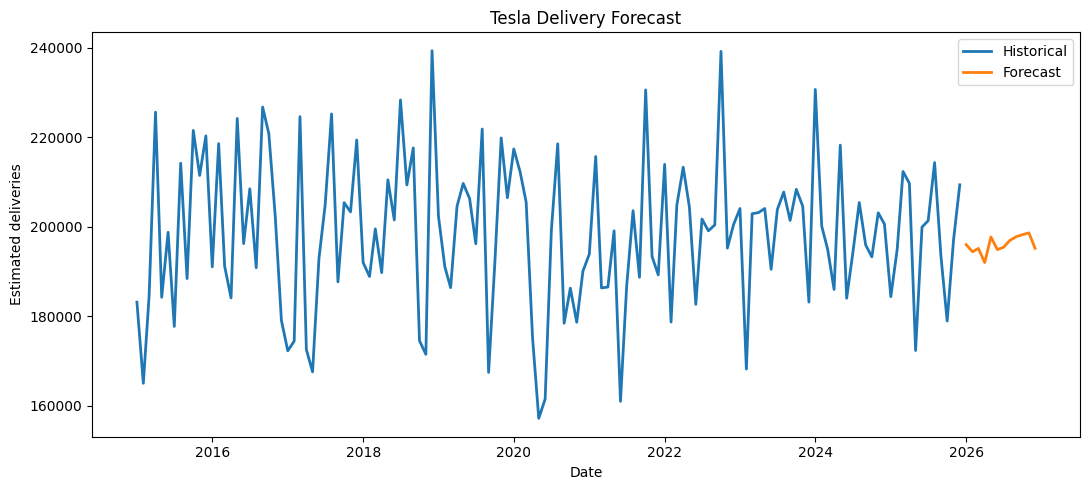

Pipeline complete. Outputs written to: c:\Users\khush\OneDrive\Desktop\celebal assesment\ml_pipeline_outputs


In [18]:
plt.figure(figsize=(11, 5))
plt.plot(monthly_ts['date'], monthly_ts['deliveries'], label='Historical', linewidth=2)
plt.plot(pd.to_datetime(forecast_df['date']), forecast_df['forecast_deliveries'], label='Forecast', linewidth=2)
plt.title('Tesla Delivery Forecast')
plt.xlabel('Date')
plt.ylabel('Estimated deliveries')
plt.legend()
plt.tight_layout()
plt.savefig(forecast_dir / 'delivery_forecast.png', dpi=140)
plt.show()

print(f'Pipeline complete. Outputs written to: {OUTPUT_DIR}')